# Phase 3 — Baseline OCR brut

**Objectif** : évaluer les performances d'un OCR appliqué **directement** sur les
documents FUNSD, sans aucun prétraitement, à la fois sur les images originales et
sur leurs versions dégradées (Phase 2), afin d'établir une baseline de référence.

**Moteur utilisé** : Tesseract OCR (via `pytesseract`), en anglais (`eng`).

**Métriques calculées** : CER (Character Error Rate), WER (Word Error Rate).

> Ce notebook est **autonome** : toutes les fonctions nécessaires (OCR, métriques)
> sont définies directement ici, sans dépendre du contenu de `src/`. Il détecte
> aussi automatiquement où se trouvent le dataset et les images dégradées de la
> Phase 2, quelle que soit leur convention de nommage.


In [1]:
import json
import platform
import os
from pathlib import Path

import cv2
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract
from jiwer import cer, wer

# Configuration automatique de Tesseract sous Windows (inutile sous Mac/Linux)
if platform.system() == "Windows":
    for _path in [r"C:\Program Files\Tesseract-OCR\tesseract.exe",
                  r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe"]:
        if os.path.exists(_path):
            pytesseract.pytesseract.tesseract_cmd = _path
            break

HERE = Path.cwd()
print("Dossier courant (cwd) :", HERE.resolve())


Dossier courant (cwd) : /Users/macbookpro/Downloads/OCR_Layout_Semantique/notebooks


## 0. Détection automatique du dataset et des images dégradées (Phase 2)

In [2]:
def find_split_dir(candidates_roots, split_names):
    for root in candidates_roots:
        for name in split_names:
            candidate = root / name
            if (candidate / "images").is_dir() and (candidate / "annotations").is_dir():
                return candidate
    return None


def find_project_root(start, markers=("src", "dataset", "data"), max_levels=8):
    current = start
    for _ in range(max_levels):
        if any((current / m).is_dir() for m in markers):
            return current
        if current.parent == current:
            break
        current = current.parent
    return None


PROJECT_ROOT = find_project_root(HERE)
if PROJECT_ROOT is None:
    raise FileNotFoundError(f"Impossible de trouver la racine du projet depuis {HERE}.")
print("Racine du projet détectée :", PROJECT_ROOT.resolve())

POSSIBLE_ROOTS = [PROJECT_ROOT, PROJECT_ROOT / "dataset", PROJECT_ROOT / "data", HERE, HERE.parent]
POSSIBLE_ROOTS = [r for r in POSSIBLE_ROOTS if r.exists()]

RAW_DIR = find_split_dir(POSSIBLE_ROOTS, ["training_data", "raw"])
if RAW_DIR is None:
    raise FileNotFoundError("Dossier d'entraînement (training_data/raw) introuvable.")
print("Dossier train détecté :", RAW_DIR.resolve())


def find_degraded_dir(dataset_root):
    candidates = [dataset_root / "degraded"]
    for child in dataset_root.iterdir() if dataset_root.is_dir() else []:
        if child.is_dir():
            candidates.append(child / "degraded")
    for c in candidates:
        if c.is_dir():
            return c
    return None


def find_manifest_file(degraded_dir):
    if degraded_dir is None:
        return None
    json_files = list(degraded_dir.glob("*.json"))
    for preferred in ["degradation_log.json", "manifest_degraded.json"]:
        for f in json_files:
            if f.name == preferred:
                return f
    for f in json_files:
        if "degrad" in f.name.lower() or "manifest" in f.name.lower():
            return f
    return json_files[0] if json_files else None


DATASET_ROOT = RAW_DIR.parent
DEGRADED_DIR = find_degraded_dir(DATASET_ROOT)
MANIFEST_FILE = find_manifest_file(DEGRADED_DIR)

print("Dossier dégradées détecté :", DEGRADED_DIR.resolve() if DEGRADED_DIR else "AUCUN")
print("Fichier manifeste détecté :", MANIFEST_FILE.resolve() if MANIFEST_FILE else "AUCUN")


Racine du projet détectée : /Users/macbookpro/Downloads/OCR_Layout_Semantique
Dossier train détecté : /Users/macbookpro/Downloads/OCR_Layout_Semantique/dataset/training_data
Dossier dégradées détecté : /Users/macbookpro/Downloads/OCR_Layout_Semantique/dataset/degraded
Fichier manifeste détecté : /Users/macbookpro/Downloads/OCR_Layout_Semantique/dataset/degraded/degradation_log.json


## 1. Fonctions OCR + métriques (autonomes)

In [3]:
def run_ocr(img, lang="eng"):
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) if len(img.shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return pytesseract.image_to_string(rgb, lang=lang).strip()


def ground_truth_text(annotation):
    return " ".join(item["text"] for item in annotation["form"])


def ocr_metrics(hypothesis, reference):
    reference, hypothesis = reference.strip(), hypothesis.strip()
    if not reference:
        return {"CER": None, "WER": None}
    return {
        "CER": round(cer(reference, hypothesis) if hypothesis else 1.0, 4),
        "WER": round(wer(reference, hypothesis) if hypothesis else 1.0, 4),
    }


def build_manifest(split_dir):
    images = sorted((split_dir / "images").glob("*.png"))
    manifest = []
    for img in images:
        ann = split_dir / "annotations" / f"{img.stem}.json"
        if ann.exists():
            manifest.append({"image": img.name, "annotation": ann.name})
    return manifest


## 2. OCR brut sur les documents originaux

> Sous-échantillon de 12 documents pour garder un temps d'exécution raisonnable.

In [4]:
manifest = build_manifest(RAW_DIR)
print(f"{len(manifest)} documents FUNSD (train set complet)")

N_SAMPLE = 12
subset = manifest[:N_SAMPLE]

records_original = []
for entry in subset:
    img_path = RAW_DIR / "images" / entry["image"]
    ann = json.loads((RAW_DIR / "annotations" / entry["annotation"]).read_text(encoding="utf-8"))
    ref_text = ground_truth_text(ann)

    img = cv2.imread(str(img_path))
    text = run_ocr(img)
    metrics = ocr_metrics(text, ref_text)

    records_original.append({"document": entry["image"], "condition": "original", **metrics})

df_original = pd.DataFrame(records_original)
df_original


149 documents FUNSD (train set complet)


,document,condition,CER,WER
0,0000971160.png,original,0.1902,0.4759
1,0000989556.png,original,0.6447,0.8750
2,0000990274.png,original,0.4113,0.5833
3,0000999294.png,original,0.8560,0.9797
4,0001118259.png,original,0.5500,0.8333
5,0001123541.png,original,0.4602,0.6402
6,0001129658.png,original,0.4034,0.6066
7,0001209043.png,original,0.8019,0.8828
8,0001239897.png,original,0.7487,0.9023
9,0001438955.png,original,0.8106,0.9583


In [5]:
print("Moyennes sur documents originaux :")
df_original[["CER", "WER"]].mean().round(3)


Moyennes sur documents originaux :


CER    0.591
WER    0.780
dtype: float64

## 3. OCR brut sur les documents dégradés (normalisation du manifeste Phase 2)

Le schéma exact des champs peut varier selon la version du notebook 02 utilisée
(`source_image` vs `document_original`, `output_image` vs `filename`...). Cette
cellule normalise tout vers un format commun.

In [6]:
def get_first(d, keys, default=None):
    for k in keys:
        if k in d and d[k]:
            return d[k]
    return default


def locate_image_file(filename, degraded_dir):
    direct = degraded_dir / filename
    if direct.exists():
        return direct
    nested = degraded_dir / "images" / filename
    if nested.exists():
        return nested
    matches = list(degraded_dir.rglob(filename))
    return matches[0] if matches else None


records_degraded = []
if MANIFEST_FILE is not None:
    raw_records = json.loads(MANIFEST_FILE.read_text(encoding="utf-8"))
    print(f"{len(raw_records)} entrées brutes dans le manifeste de dégradation")

    normalized = []
    for r in raw_records:
        source_image = get_first(r, ["source_image", "document_original", "document", "source"])
        degradation_name = get_first(r, ["degradation"])
        level = get_first(r, ["level_name", "level"])
        output_name = get_first(r, ["output_image", "filename", "image", "path"])
        if output_name is None and source_image and degradation_name and level:
            stem = Path(source_image).stem
            output_name = f"{stem}__{degradation_name}__{level}.png"
        img_path = locate_image_file(Path(output_name).name, DEGRADED_DIR) if output_name else None
        if source_image and img_path is not None:
            normalized.append({"source_image": source_image, "degradation": degradation_name,
                                "level_name": level, "image_path": img_path})

    df_norm = pd.DataFrame(normalized)
    print(f"{len(df_norm)} entrées localisées sur le disque")

    N_DEGRADED = 40
    for _, row in df_norm.head(N_DEGRADED).iterrows():
        ann_path = RAW_DIR / "annotations" / f"{Path(row['source_image']).stem}.json"
        if not ann_path.exists():
            continue
        ann = json.loads(ann_path.read_text(encoding="utf-8"))
        ref_text = ground_truth_text(ann)
        img = cv2.imread(str(row["image_path"]))
        if img is None:
            continue
        text = run_ocr(img)
        metrics = ocr_metrics(text, ref_text)
        records_degraded.append({"document": row["source_image"], "degradation": row["degradation"],
                                  "level_name": row["level_name"], **metrics})
else:
    print("Aucun manifeste de dégradation trouvé : exécute d'abord 02_degradation_generation.ipynb.")

df_degraded = pd.DataFrame(records_degraded)
df_degraded.head(10)


288 entrées brutes dans le manifeste de dégradation
288 entrées localisées sur le disque


,document,degradation,level_name,CER,WER
0,0000971160.png,blur,faible,0.4263,0.6552
1,0000971160.png,blur,moyen,0.9101,0.9586
2,0000971160.png,blur,fort,0.9592,1.0000
3,0000971160.png,noise,faible,0.1839,0.4897
4,0000971160.png,noise,moyen,0.1870,0.4621
5,0000971160.png,noise,fort,1.0000,1.0000
6,0000971160.png,rotation,faible,0.2257,0.5241
7,0000971160.png,rotation,moyen,0.4211,0.7103
8,0000971160.png,rotation,fort,0.2330,0.5793
9,0000971160.png,low_contrast,faible,0.1870,0.4621


## 4. Comparaison : impact de chaque dégradation sur le CER/WER

In [7]:
if not df_degraded.empty:
    summary = df_degraded.groupby(["degradation", "level_name"])[["CER", "WER"]].mean().reset_index()
    baseline_row = pd.DataFrame([{"degradation": "aucune (original)", "level_name": "-",
                                   "CER": df_original["CER"].mean(), "WER": df_original["WER"].mean()}])
    summary_full = pd.concat([baseline_row, summary], ignore_index=True)

    results_dir = PROJECT_ROOT / "results" / "tables"
    results_dir.mkdir(parents=True, exist_ok=True)
    summary_full.to_csv(results_dir / "phase3_ocr_baseline_summary.csv", index=False)
    display(summary_full.round(3))
else:
    print("Pas de données dégradées à résumer.")


,degradation,level_name,CER,WER
0,aucune (original),-,0.591,0.780
1,blur,faible,0.595,0.778
2,blur,fort,0.933,1.000
3,blur,moyen,0.831,0.962
4,jpeg,faible,0.423,0.671
5,jpeg,fort,0.441,0.724
6,jpeg,moyen,0.450,0.707
7,low_contrast,faible,0.418,0.664
8,low_contrast,fort,0.421,0.665
9,low_contrast,moyen,0.419,0.666


## 5. Visualisation : CER moyen par type de dégradation

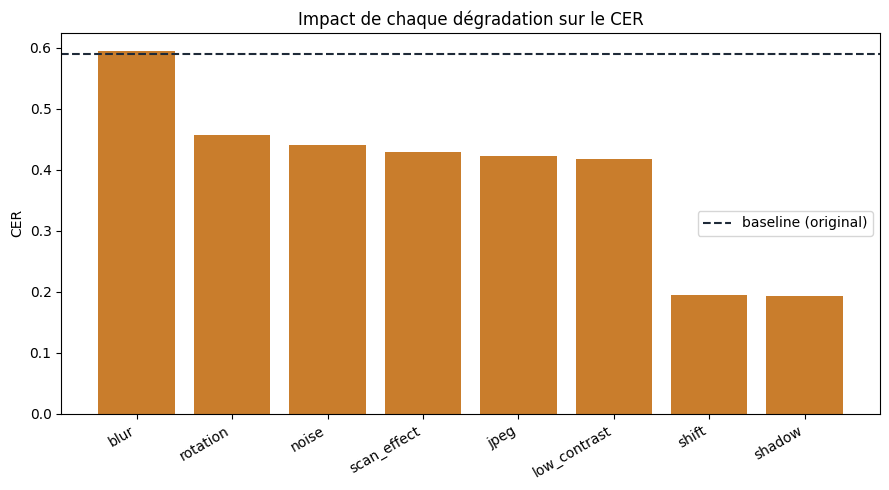

In [8]:
if not df_degraded.empty:
    moyen_df = summary[summary["level_name"] == summary["level_name"].mode()[0]].sort_values("CER", ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(moyen_df["degradation"], moyen_df["CER"], color="#C97D2C")
    ax.axhline(df_original["CER"].mean(), color="#1E2A38", linestyle="--", label="baseline (original)")
    ax.set_ylabel("CER")
    ax.set_title("Impact de chaque dégradation sur le CER")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    fig_dir = PROJECT_ROOT / "results" / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_dir / "phase3_cer_by_degradation.png", dpi=110)
    plt.show()


## 6. Résultats attendus de la Phase 3 — récapitulatif

- **Notebook OCR baseline**, autonome, exécuté sur un sous-échantillon de documents
  originaux et dégradés.
- **Tableau de résultats** : `results/tables/phase3_ocr_baseline_summary.csv`.
- **Prochaine étape (Phase 4)** : appliquer les prétraitements d'image et comparer
  les gains obtenus par rapport à cette baseline (voir `04_preprocessing_ocr.ipynb`).
